Preprocessed dataset loaded: (48536, 28)


,Patient_ID,Age,HTT_CAG_Repeat_Length,Motor_Symptoms,Cognitive_Decline,Chorea_Score,Brain_Volume_Loss,Functional_Capacity,HTT_Gene_Expression_Level,Protein_Aggregation_Level,...,Gene_Mutation_Type_Point Mutation,Category_Primary Cause,Category_Trans-acting Modifier,Gene/Factor_HTT (Somatic Expansion),Gene/Factor_MLH1,Gene/Factor_MSH3,Function_CAG Trinucleotide Repeat Expansion,Function_Mismatch Repair,Effect_Faster Disease Onset,Effect_Neurodegeneration
0,b2a49170-8561-4665-9371-2240b55dd87a,-1.630576,0.714972,2,3,1.313501,-1.100404,1.495241,0.533420,-1.390031,...,0,1,0,0,0,0,1,0,0,1
1,f5fae45d-8718-41c4-a957-6928f79f3c8e,-1.495093,-1.471395,3,2,-0.605530,0.383865,-0.012156,-1.620850,-1.587949,...,1,1,0,0,0,0,1,0,0,1
2,66ab0567-050b-4d56-9ec4-b676309899a6,0.943601,-1.546787,3,2,-1.375213,-1.303289,0.638765,-0.579861,-1.064881,...,0,0,1,0,0,1,0,1,0,0
3,996a48e4-e841-418f-a539-5a7a86cd815d,0.740376,-0.566692,1,3,-0.615884,0.805654,0.878578,-0.203948,-0.478197,...,0,0,1,0,0,1,0,1,0,0
4,d45c7ca8-7125-4aaa-8018-5bbc60d35a1f,-0.817678,-0.717475,2,1,-0.926519,1.211425,0.673024,0.793668,0.278131,...,0,0,0,1,0,0,0,0,1,0



CATBOOST | TARGET: Motor_Symptoms
Train: (33974, 23) Val: (4854, 23) Test: (9708, 23)

VALIDATION METRICS: {'Accuracy': 0.3273588792748249, 'Precision': 0.3273726739735832, 'Recall': 0.3273588792748249, 'F1': 0.32730182682186754}
TEST METRICS      : {'Accuracy': 0.3318912237330037, 'Precision': 0.33176710973819284, 'Recall': 0.3318912237330037, 'F1': 0.33174313353424406}

Classification Report (TEST):

              precision    recall  f1-score   support

        Mild       0.33      0.31      0.32      3224
    Moderate       0.33      0.34      0.34      3252
      Severe       0.33      0.34      0.34      3232

    accuracy                           0.33      9708
   macro avg       0.33      0.33      0.33      9708
weighted avg       0.33      0.33      0.33      9708



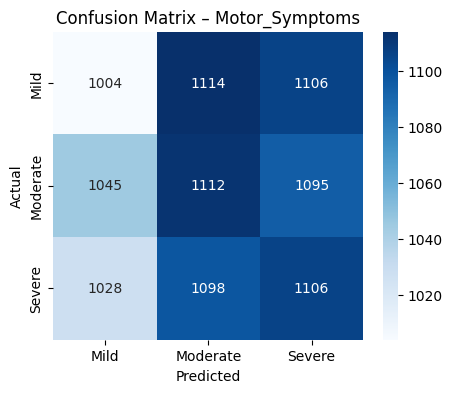

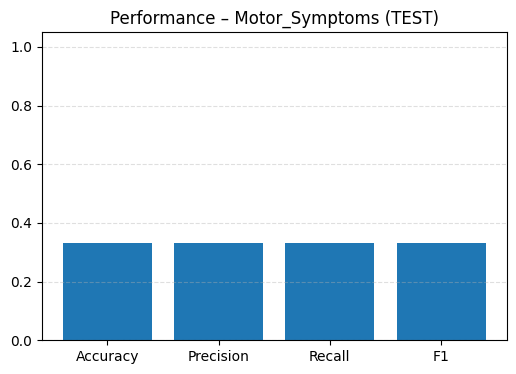


CATBOOST | TARGET: Disease_Stage
Train: (33974, 23) Val: (4854, 23) Test: (9708, 23)

VALIDATION METRICS: {'Accuracy': 0.23588792748248866, 'Precision': 0.23601424443391256, 'Recall': 0.23588792748248866, 'F1': 0.23539691678680086}
TEST METRICS      : {'Accuracy': 0.24526163988463123, 'Precision': 0.24484406614180476, 'Recall': 0.24526163988463123, 'F1': 0.2446442534031126}

Classification Report (TEST):

                 precision    recall  f1-score   support

Pre-Symptomatic       0.25      0.27      0.26      2438
          Early       0.23      0.22      0.23      2407
         Middle       0.25      0.27      0.26      2458
           Late       0.24      0.22      0.23      2405

       accuracy                           0.25      9708
      macro avg       0.24      0.25      0.24      9708
   weighted avg       0.24      0.25      0.24      9708



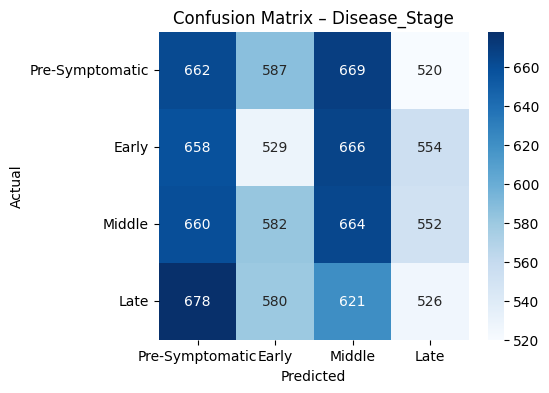

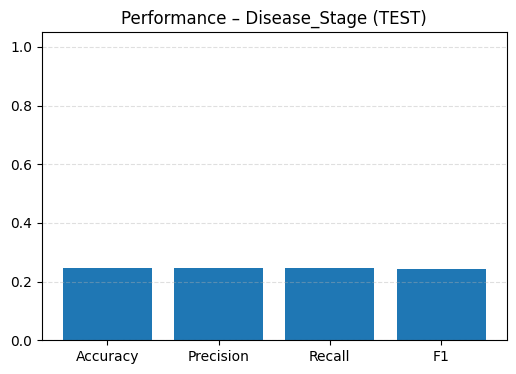


CATBOOST | TARGET: Category
Train: (33974, 22) Val: (4854, 22) Test: (9708, 22)

VALIDATION METRICS: {'Accuracy': 1.0, 'Precision': 1.0, 'Recall': 1.0, 'F1': 1.0}
TEST METRICS      : {'Accuracy': 1.0, 'Precision': 1.0, 'Recall': 1.0, 'F1': 1.0}

Classification Report (TEST):

                       precision    recall  f1-score   support

        Primary Cause       1.00      1.00      1.00      2446
Trans-acting Modifier       1.00      1.00      1.00      4856
  Cis-acting Modifier       1.00      1.00      1.00      2406

             accuracy                           1.00      9708
            macro avg       1.00      1.00      1.00      9708
         weighted avg       1.00      1.00      1.00      9708



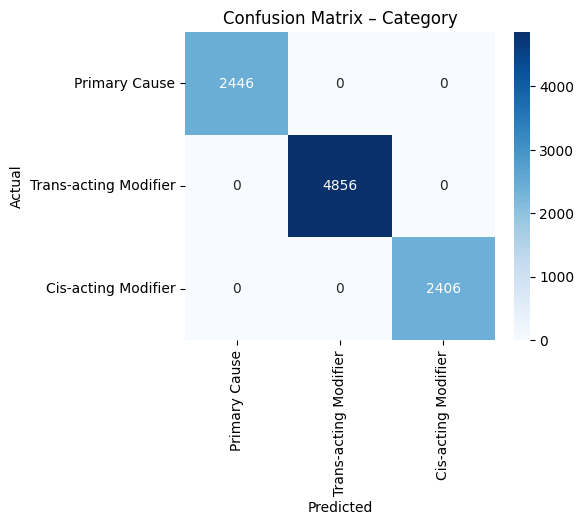

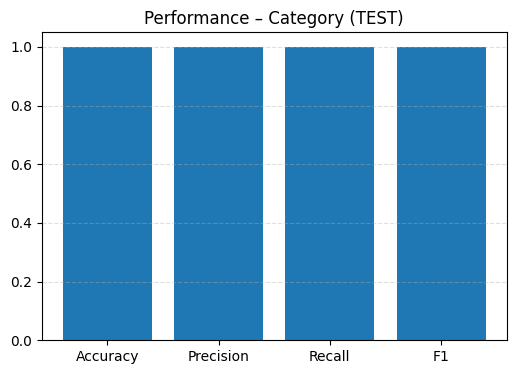


PER-TARGET COMPARISON TABLE


,Target,Split,Accuracy,Precision,Recall,F1
0,Motor_Symptoms,Validation,0.327359,0.327373,0.327359,0.327302
1,Motor_Symptoms,Test,0.331891,0.331767,0.331891,0.331743
2,Disease_Stage,Validation,0.235888,0.236014,0.235888,0.235397
3,Disease_Stage,Test,0.245262,0.244844,0.245262,0.244644
4,Category,Validation,1.000000,1.000000,1.000000,1.000000
5,Category,Test,1.000000,1.000000,1.000000,1.000000



FINAL SUMMARY TABLE (Mean of Val & Test)


,Target,Accuracy,Precision,Recall,F1
0,Category,1.000000,1.000000,1.000000,1.000000
1,Disease_Stage,0.240575,0.240429,0.240575,0.240021
2,Motor_Symptoms,0.329625,0.329570,0.329625,0.329522


In [9]:

!pip -q install catboost

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
from catboost import CatBoostClassifier

# =========================
# LOAD PREPROCESSED DATASET
# =========================
path = "/content/drive/MyDrive/Dataset/Huntington_Disease_Dataset_Preprocessed_Scaled.csv.gz"
df = pd.read_csv(path)

print("Preprocessed dataset loaded:", df.shape)
display(df.head())

# =========================
# HELPERS
# =========================
def plot_confusion(cm, labels, title):
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=labels, yticklabels=labels)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

def plot_performance(m, title):
    plt.figure(figsize=(6,4))
    plt.bar(["Accuracy","Precision","Recall","F1"],
            [m["Accuracy"], m["Precision"], m["Recall"], m["F1"]])
    plt.ylim(0, 1.05)
    plt.title(title)
    plt.grid(axis="y", linestyle="--", alpha=0.4)
    plt.show()

def get_metrics(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "Recall": recall_score(y_true, y_pred, average="weighted", zero_division=0),
        "F1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
    }

# =========================
# CATEGORY TARGET (NO LEAKAGE)
# - If 'Category' exists, use it
# - Else build from Primary/Trans one-hot
# =========================
def prepare_category(df):
    # If Category exists (string or numeric)
    if "Category" in df.columns:
        if df["Category"].dtype == object:
            le = LabelEncoder()
            y = le.fit_transform(df["Category"].astype(str))
            class_names = list(le.classes_)
        else:
            y = df["Category"].astype(int).values
            class_names = ["Primary Cause","Trans-acting Modifier","Cis-acting Modifier"]
        drop_cols = ["Category"]
        return y, class_names, drop_cols

    # One-hot (try to detect)
    primary_candidates = [c for c in df.columns if "Category" in c and "Primary" in c]
    trans_candidates   = [c for c in df.columns if "Category" in c and "Trans" in c]
    if len(primary_candidates) == 0 or len(trans_candidates) == 0:
        raise ValueError("No usable Category columns found (no 'Category' and no Primary/Trans one-hot).")

    primary_col = primary_candidates[0]
    trans_col = trans_candidates[0]

    y = np.where(df[primary_col] == 1, 0,
         np.where(df[trans_col] == 1, 1, 2))

    class_names = ["Primary Cause","Trans-acting Modifier","Cis-acting Modifier"]
    drop_cols = [primary_col, trans_col]  # leakage columns to drop
    return y, class_names, drop_cols

# =========================
# MAIN: SPLIT FIRST -> TRAIN CATBOOST -> EVALUATE
# =========================
def run_catboost(df, target_name, class_names=None):

    # ----- y and leakage drop cols -----
    if target_name == "Category":
        y, class_names, drop_cols = prepare_category(df)
    else:
        if target_name not in df.columns:
            print(f"❌ Target not found: {target_name}")
            return None

        # If numeric, use as-is; else encode
        if np.issubdtype(df[target_name].dtype, np.number):
            y = df[target_name].astype(int).values
        else:
            y = LabelEncoder().fit_transform(df[target_name].astype(str))

        drop_cols = [target_name]

        # defaults
        if class_names is None:
            if target_name == "Motor_Symptoms":
                class_names = ["Mild","Moderate","Severe"]
            elif target_name == "Disease_Stage":
                class_names = ["Pre-Symptomatic","Early","Middle","Late"]
            else:
                class_names = [str(i) for i in sorted(np.unique(y))]

    # ----- X numeric only (preprocessed expected) -----
    X_df = df.drop(columns=drop_cols, errors="ignore").copy()
    X_df = X_df.select_dtypes(exclude=["object"])
    X = X_df.values

    # ----- SPLIT FIRST: 70/10/20 -----
    X_trainval, X_test, y_trainval, y_test = train_test_split(
        X, y, test_size=0.20, random_state=42, stratify=y
    )
    X_train, X_val, y_train, y_val = train_test_split(
        X_trainval, y_trainval, test_size=0.125, random_state=42, stratify=y_trainval
    )

    print("\n" + "="*70)
    print("CATBOOST | TARGET:", target_name)
    print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)
    print("="*70)

    # ----- Model -----
    model = CatBoostClassifier(
        iterations=800,
        learning_rate=0.05,
        depth=6,
        loss_function="MultiClass",
        random_seed=42,
        verbose=0
    )

    model.fit(X_train, y_train)

    # ----- Predict -----
    val_pred  = model.predict(X_val).astype(int).reshape(-1)
    test_pred = model.predict(X_test).astype(int).reshape(-1)

    # ----- Metrics -----
    val_m = get_metrics(y_val, val_pred)
    test_m = get_metrics(y_test, test_pred)

    print("\nVALIDATION METRICS:", val_m)
    print("TEST METRICS      :", test_m)

    print("\nClassification Report (TEST):\n")
    print(classification_report(y_test, test_pred, target_names=class_names, zero_division=0))

    # ----- Plots (Test) -----
    cm = confusion_matrix(y_test, test_pred)
    plot_confusion(cm, class_names, f"Confusion Matrix – {target_name}")
    plot_performance(test_m, f"Performance – {target_name} (TEST)")

    # Return results in a table-friendly form
    return {
        "Target": target_name,
        "Model": "CatBoost",
        "Val": val_m,
        "Test": test_m
    }

# =========================
# RUN ALL TARGETS
# =========================
results = []
results.append(run_catboost(df, "Motor_Symptoms", ["Mild","Moderate","Severe"]))
results.append(run_catboost(df, "Disease_Stage", ["Pre-Symptomatic","Early","Middle","Late"]))
results.append(run_catboost(df, "Category"))

# =========================
# PER-TARGET COMPARISON TABLE (Val & Test)
# =========================
rows = []
for r in results:
    if r is None:
        continue
    for split in ["Val", "Test"]:
        m = r[split]
        rows.append({
            "Target": r["Target"],
            "Split": "Validation" if split == "Val" else "Test",
            "Accuracy": m["Accuracy"],
            "Precision": m["Precision"],
            "Recall": m["Recall"],
            "F1": m["F1"]
        })

comparison_df = pd.DataFrame(rows)

print("\n==============================")
print("PER-TARGET COMPARISON TABLE")
print("==============================")
display(comparison_df)

# =========================
# FINAL SUMMARY TABLE (mean of Val+Test per target)
# =========================
summary_df = (
    comparison_df
    .groupby("Target")[["Accuracy","Precision","Recall","F1"]]
    .mean()
    .reset_index()
)

print("\n==============================")
print("FINAL SUMMARY TABLE (Mean of Val & Test)")
print("==============================")
display(summary_df)


In [10]:
# =========================
# OVERALL ACCURACY (VAL & TEST)
# =========================
overall_accuracy_df = (
    comparison_df
    .groupby("Split")["Accuracy"]
    .mean()
    .reset_index()
)

print("\n==============================")
print("OVERALL ACCURACY (AVERAGED)")
print("==============================")
display(overall_accuracy_df)



OVERALL ACCURACY (AVERAGED)


,Split,Accuracy
0,Test,0.525718
1,Validation,0.521082


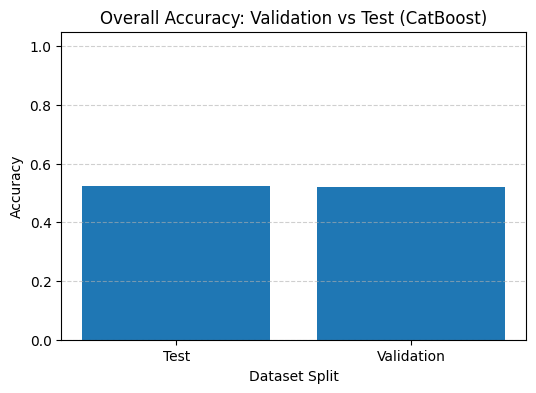

In [11]:
# =========================
# OVERALL VAL vs TEST GRAPH
# =========================
plt.figure(figsize=(6,4))

plt.bar(
    overall_accuracy_df["Split"],
    overall_accuracy_df["Accuracy"]
)

plt.title("Overall Accuracy: Validation vs Test (CatBoost)")
plt.xlabel("Dataset Split")
plt.ylabel("Accuracy")
plt.ylim(0, 1.05)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()


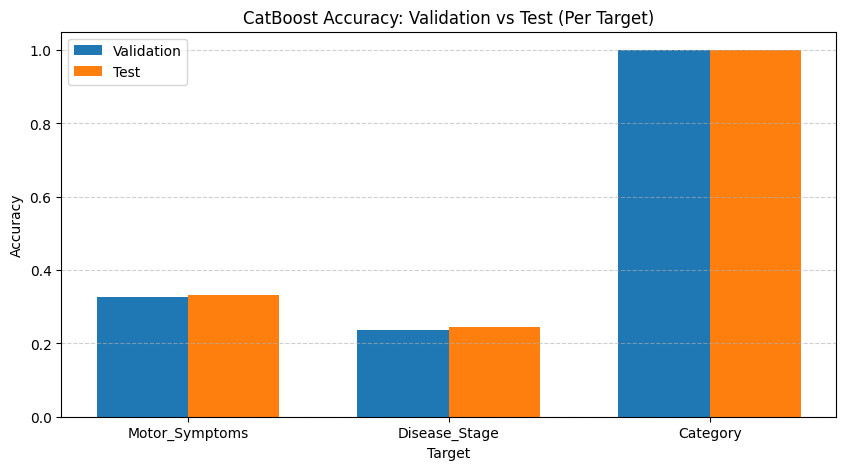

In [12]:
# =========================
# PER-TARGET VAL vs TEST ACCURACY GRAPH
# =========================
targets = comparison_df["Target"].unique()
x = np.arange(len(targets))
bar_width = 0.35

val_acc = comparison_df[comparison_df["Split"]=="Validation"]["Accuracy"].values
test_acc = comparison_df[comparison_df["Split"]=="Test"]["Accuracy"].values

plt.figure(figsize=(10,5))
plt.bar(x - bar_width/2, val_acc, width=bar_width, label="Validation")
plt.bar(x + bar_width/2, test_acc, width=bar_width, label="Test")

plt.xticks(x, targets)
plt.title("CatBoost Accuracy: Validation vs Test (Per Target)")
plt.xlabel("Target")
plt.ylabel("Accuracy")
plt.ylim(0, 1.05)
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.show()
